# Building and Using an SMA Backtester Class

This notebook shows how to build a reusable object-oriented workflow for an SMA crossover strategy. Instead of rewriting the same backtest logic again and again, we will create a `SMABacktester` class that can load data, prepare signals, backtest performance, plot results, change parameters, optimise parameter combinations, and compare in-sample and out-of-sample behaviour.

> **Disclaimer**
>
> This notebook is for educational purposes only. It is **not** financial advice. The examples are simplified and do not include important real-world considerations such as transaction costs, spreads, slippage, position sizing, risk controls, and forward testing. Real trading requires much more validation than a simple historical backtest.


## 1. Import Libraries

We use `pandas` and `numpy` for data handling, `matplotlib` for charts, `itertools.product` for parameter search, and `Path` for file handling.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import product
from pathlib import Path

pd.options.display.float_format = '{:,.6f}'.format
plt.style.use('default')


## 2. Load or Generate Data

The notebook first looks for `forex_pairs.csv`. If the file is missing, it creates a synthetic example dataset with three FX-style instruments, adds a few missing values, saves the file, and then loads it back in the same way we would load a real dataset.


             EURUSD   AUDEUR   USDGBP
Date                                 
2004-01-01 1.201671 0.650033 0.549273
2004-01-02 1.196084 0.650040 0.547288
2004-01-05 1.200154 0.650722 0.551852
2004-01-06 1.205269 0.656196 0.550792
2004-01-07 1.194757 0.657086 0.549739

             EURUSD   AUDEUR   USDGBP
Date                                 
2020-06-24 1.003797 0.702872 0.352622
2020-06-25 1.001816 0.706153 0.351671
2020-06-26 1.006790 0.703052 0.350448
2020-06-29 1.003543 0.708153 0.349072
2020-06-30 1.000881 0.704376 0.348741

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4304 entries, 2004-01-01 to 2020-06-30
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   EURUSD  4294 non-null   float64
 1   AUDEUR  4294 non-null   float64
 2   USDGBP  4294 non-null   float64
dtypes: float64(3)
memory usage: 134.5 KB


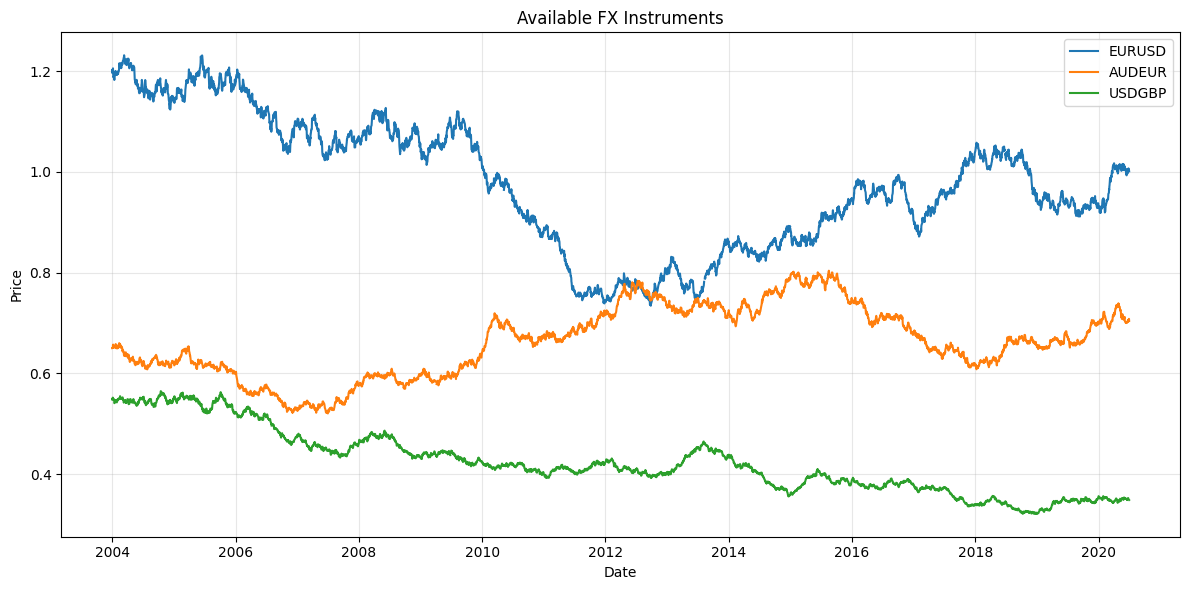

In [2]:
data_path = Path("forex_pairs.csv")

if not data_path.exists():
    rng = np.random.default_rng(42)
    dates = pd.date_range("2004-01-01", "2020-06-30", freq="B")
    n = len(dates)

    def make_fx_series(start_level, drift, vol):
        log_returns = rng.normal(loc=drift, scale=vol, size=n)
        return start_level * np.exp(np.cumsum(log_returns))

    synthetic = pd.DataFrame({
        "Date": dates,
        "EURUSD": make_fx_series(1.20, 0.00002, 0.0045),
        "AUDEUR": make_fx_series(0.65, 0.00001, 0.0040),
        "USDGBP": make_fx_series(0.55, -0.00001, 0.0038),
    })

    # Add a few missing values to imitate real-world data issues.
    for column in ["EURUSD", "AUDEUR", "USDGBP"]:
        missing_idx = rng.choice(n, size=10, replace=False)
        synthetic.loc[missing_idx, column] = np.nan

    synthetic.to_csv(data_path, index=False)
    print("Created synthetic forex_pairs.csv")

df = pd.read_csv(data_path, parse_dates=["Date"])
df = df.set_index("Date").sort_index()

print(df.head())
print()
print(df.tail())
print()
df.info()

plt.figure(figsize=(12, 6))
for column in df.columns:
    plt.plot(df.index, df[column], label=column)
plt.title("Available FX Instruments")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 3. Create the `SMABacktester` Class

This class wraps the full workflow: loading one instrument, preparing returns and moving averages, building a trading signal, backtesting the strategy, plotting results, changing parameters, and optimising over many SMA combinations.


In [ ]:
class SMABacktester:
    def __init__(self, symbol, sma_short, sma_long, start, end, data_path="forex_pairs.csv"):
        self.symbol = symbol
        self.sma_short = sma_short
        self.sma_long = sma_long
        self.start = start
        self.end = end
        self.data_path = Path(data_path)
        self.data = None
        self.results = None
        self.optimization_results = None
        self.get_data()
        self.prepare_data()

    def __repr__(self):
        return (
            f"SMABacktester(symbol={self.symbol}, SMA_Short={self.sma_short}, "
            f"SMA_Long={self.sma_long}, start={self.start}, end={self.end})"
        )

    def get_data(self):
        data = pd.read_csv(self.data_path, parse_dates=["Date"])
        data = data.set_index("Date").sort_index()

        if self.symbol not in data.columns:
            raise ValueError(f"Symbol {self.symbol} not found in {self.data_path}.")

        data = data[[self.symbol]].rename(columns={self.symbol: "price"})
        data = data.loc[self.start:self.end].copy()
        data = data.dropna().copy()
        data["returns"] = np.log(data["price"] / data["price"].shift(1))
        self.data = data.dropna().copy()

    def prepare_data(self):
        data = self.data.copy()
        data["SMA_Short"] = data["price"].rolling(self.sma_short).mean()
        data["SMA_Long"] = data["price"].rolling(self.sma_long).mean()
        data = data.dropna().copy()
        data["position"] = np.where(data["SMA_Short"] > data["SMA_Long"], 1, -1)
        data["strategy"] = data["position"].shift(1) * data["returns"]
        data = data.dropna().copy()
        data["cret"] = np.exp(data["returns"].cumsum())
        data["cstrategy"] = np.exp(data["strategy"].cumsum())
        self.results = data

    def set_parameters(self, sma_short=None, sma_long=None):
        if sma_short is not None:
            self.sma_short = sma_short
        if sma_long is not None:
            self.sma_long = sma_long
        self.prepare_data()

    def test_strategy(self):
        strategy_perf = self.results["cstrategy"].iloc[-1]
        bh_perf = self.results["cret"].iloc[-1]
        outperformance = strategy_perf - bh_perf

        strategy_perf = round(float(strategy_perf), 6)
        bh_perf = round(float(bh_perf), 6)
        outperformance = round(float(outperformance), 6)

        print(f"Strategy Performance: {strategy_perf}")
        print(f"Buy and Hold Performance: {bh_perf}")
        print(f"Outperformance: {outperformance}")
        return strategy_perf, outperformance

    def plot_results(self):
        plt.figure(figsize=(12, 6))
        plt.plot(self.results.index, self.results["cret"], label="Buy and Hold")
        plt.plot(self.results.index, self.results["cstrategy"], label="SMA Strategy")
        plt.title(f"{self.symbol} | SMA {self.sma_short}/{self.sma_long}")
        plt.xlabel("Date")
        plt.ylabel("Cumulative Growth")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

    def optimize_parameters(self, sma_short_range, sma_long_range):
        short_values = range(*sma_short_range)
        long_values = range(*sma_long_range)
        results = []

        for sma_short, sma_long in product(short_values, long_values):
            if sma_short < sma_long:
                self.set_parameters(sma_short=sma_short, sma_long=sma_long)
                performance = float(self.results["cstrategy"].iloc[-1])
                outperformance = float(self.results["cstrategy"].iloc[-1] - self.results["cret"].iloc[-1])
                results.append((sma_short, sma_long, performance, outperformance))

        self.optimization_results = pd.DataFrame(
            results,
            columns=["SMA_Short", "SMA_Long", "Performance", "Outperformance"]
        ).sort_values("Performance", ascending=False).reset_index(drop=True)

        best_row = self.optimization_results.iloc[0]
        best_short = int(best_row["SMA_Short"])
        best_long = int(best_row["SMA_Long"])
        best_performance = round(float(best_row["Performance"]), 6)

        self.set_parameters(sma_short=best_short, sma_long=best_long)
        return (best_short, best_long), best_performance


## 4. Demonstrate the Class

We start with a standard EUR/USD tester using SMA 50 and SMA 200, then inspect the object, preview the prepared results, run the backtest, and plot cumulative performance.


In [ ]:
tester = SMABacktester(
    symbol="EURUSD",
    sma_short=50,
    sma_long=200,
    start="2004-01-01",
    end="2020-06-30"
)

print(tester)
tester.results.head()


In [ ]:
tester.test_strategy()
tester.plot_results()


## 5. Change Strategy Parameters

A main benefit of the class structure is that we can retest a different SMA combination quickly without rewriting the strategy code.


In [ ]:
tester.set_parameters(sma_short=75, sma_long=150)
tester.test_strategy()
tester.plot_results()


## 6. Optimise SMA Parameters

We now search across many SMA combinations to find the best historical result for this sample. This is an in-sample optimization, so it can easily lead to overfitting.


In [ ]:
best_params, best_perf = tester.optimize_parameters(
    sma_short_range=(25, 50, 1),
    sma_long_range=(100, 200, 1)
)

print("Best parameters:", best_params)
print("Best performance:", best_perf)
print()
print("Top 10 parameter combinations:")
print(tester.optimization_results.head(10))

tester.plot_results()


## 7. Visualise the Optimization Surface

A heatmap helps us see whether performance is concentrated in a small region or whether a wider area of SMA combinations behaves similarly.


In [ ]:
pivot = tester.optimization_results.pivot(index="SMA_Short", columns="SMA_Long", values="Performance")

plt.figure(figsize=(12, 6))
image = plt.imshow(
    pivot,
    aspect="auto",
    origin="lower",
    extent=[pivot.columns.min(), pivot.columns.max(), pivot.index.min(), pivot.index.max()]
)
plt.colorbar(image, label="Performance")
plt.title("EURUSD SMA Optimization Heatmap")
plt.xlabel("SMA_Long")
plt.ylabel("SMA_Short")
plt.tight_layout()
plt.show()


## 8. In-Sample / Out-of-Sample Test

Next, we fit the strategy on a training period and then test the selected parameters on unseen data. This is a much healthier workflow than optimising and judging everything on the same sample.


In [ ]:
train_tester = SMABacktester("EURUSD", 50, 200, "2004-01-01", "2015-12-31")
train_best_params, train_best_perf = train_tester.optimize_parameters((25, 50, 1), (100, 200, 1))
print("Training best parameters:", train_best_params)
print("Training best performance:", train_best_perf)
train_tester.plot_results()

best_sma_short, best_sma_long = train_best_params


In [ ]:
test_tester = SMABacktester("EURUSD", best_sma_short, best_sma_long, "2016-01-01", "2020-06-30")
test_tester.test_strategy()
test_tester.plot_results()


- The strategy is fitted on the training data.
- The selected parameters are then tested on unseen future data.
- Out-of-sample performance is usually weaker than in-sample performance.
- This is one reason forward testing matters so much in systematic trading.


## 9. Test a Second Instrument

A strategy that looks good on one instrument may look much less impressive on another. That is why cross-instrument testing is useful when we want to judge how robust an idea really is.


In [ ]:
aud_tester = SMABacktester("AUDEUR", 50, 200, "2004-01-01", "2020-06-30")
aud_tester.test_strategy()
aud_tester.plot_results()


In [ ]:
aud_best_params, aud_best_perf = aud_tester.optimize_parameters((25, 50, 1), (100, 200, 1))
print("AUDEUR best parameters:", aud_best_params)
print("AUDEUR best performance:", aud_best_perf)
print()
print(aud_tester.optimization_results.head(10))
aud_tester.plot_results()


If most of the apparent outperformance comes from a short unstable period, the strategy may not be reliable. Looking across multiple instruments helps us separate a genuinely useful idea from a lucky historical pattern.


## 10. Final Summary

- A class makes backtesting reusable and easier to manage.
- SMA crossover strategies can be tested quickly across instruments and parameter values.
- Optimisation finds the best historical parameters, but that does not guarantee future success.
- In-sample and out-of-sample testing are essential.
- Real strategies still need transaction costs, spread, slippage, risk controls, position sizing, and paper/live validation before they are taken seriously.
